In [1]:
####

## SILNIK DANYCH DLA DASHBOARDU (KONSUMENT W TLE)
##
## Nasłuchuje na dwóch topicach Kafki naraz: 'sensor_readings' (zwykłe dane) oraz 'alerts' (ostrzeżenia z modeli).
## Utrzymuje w pamięci RAM podręczną pulę danych dla wykresów (np. bufor tylko 50 ostatnich odczytów).
## Działa w tle - nie blokuje działania komórki z wykresami, pozwalając im na płynne odświeżanie się.
## Co 10 sekund automatycznie wykonuje zrzut całego stanu (odczyty, alerty, statystyki)
##    do pliku 'dane_pomiarowe.json', tworząc trwałą kopię zapasową.

####


from collections import deque
import json
from kafka import KafkaConsumer
import threading
from datetime import datetime
import time

BROKER = 'broker:9092'

# Przechowywanie danych
readings = []
readings_short = deque(maxlen=50)
alerts = []
sensor_data = {}

# Plik do zapisu
DATA_FILE = 'dane_pomiarowe.json'
LAST_SAVE = time.time()
SAVE_INTERVAL = 10  # zapis co 10 sekund

def zapisz_dane():
    """Zapisuje dane do pliku JSON"""
    try:
        readings_to_save = []
        for r in readings:
            r_copy = r.copy()
            r_copy['timestamp'] = r_copy['timestamp'].isoformat()
            readings_to_save.append(r_copy)
        
        alerts_to_save = []
        for a in alerts:
            a_copy = a.copy()
            a_copy['timestamp'] = a_copy['timestamp'].isoformat()
            alerts_to_save.append(a_copy)
        
        data_to_save = {
            'readings': readings_to_save,
            'alerts': alerts_to_save,
            'sensor_data': sensor_data,
            'last_update': datetime.now().isoformat(),
            'total_readings': len(readings),
            'total_alerts': len(alerts)
        }
        
        with open(DATA_FILE, 'w') as f:
            json.dump(data_to_save, f, indent=2)
        print(f"Zapisano {len(readings)} odczytow")
    except Exception as e:
        print(f"Błąd zapisu: {e}")

def konsument():
    global LAST_SAVE
    try:
        consumer = KafkaConsumer(
            'sensor_readings', 'alerts',
            bootstrap_servers=BROKER,
            auto_offset_reset='latest',
            value_deserializer=lambda x: json.loads(x.decode('utf-8'))
        )
        print("Konsument Kafki uruchomiony. Nasłuchuje dane...")
        
        for msg in consumer:
            data = msg.value
            data['timestamp'] = datetime.now()
            if msg.topic == 'sensor_readings':
                readings.append(data)
                readings_short.append(data)
                sensor_data[data.get('sensor_id')] = data.get('pm25', 0)
            else:
                alerts.append(data)            
            # Zapisz dane co SAVE_INTERVAL sekund
            if time.time() - LAST_SAVE > SAVE_INTERVAL:
                zapisz_dane()
                LAST_SAVE = time.time()
    except Exception as e:
        print(f"Błąd Kafki: {e}")
    finally:
        if consumer:
            consumer.close()
            print("Konsument zamknięty")

# Uruchom konsumenta w tle
thread = threading.Thread(target=konsument, daemon=True)
thread.start()

print("=" * 60)
print("DASHBOARD MONITORINGU JAKOSCI POWIETRZA")
print("=" * 60)
print(f"Status: Uruchomiony")
print(f"Dane zapisywane do: {DATA_FILE} (co {SAVE_INTERVAL} sekund)")
print("=" * 60)

DASHBOARD MONITORINGU JAKOSCI POWIETRZA
Status: Uruchomiony
Dane zapisywane do: dane_pomiarowe.json (co 10 sekund)
Konsument Kafki uruchomiony. Nasłuchuje dane...
Zapisano 21 odczytow
Zapisano 41 odczytow
Zapisano 61 odczytow
Zapisano 82 odczytow
Zapisano 102 odczytow
Zapisano 122 odczytow
Zapisano 142 odczytow
Zapisano 163 odczytow
Zapisano 183 odczytow
Zapisano 203 odczytow
Zapisano 223 odczytow
Zapisano 244 odczytow
Zapisano 264 odczytow
Zapisano 284 odczytow


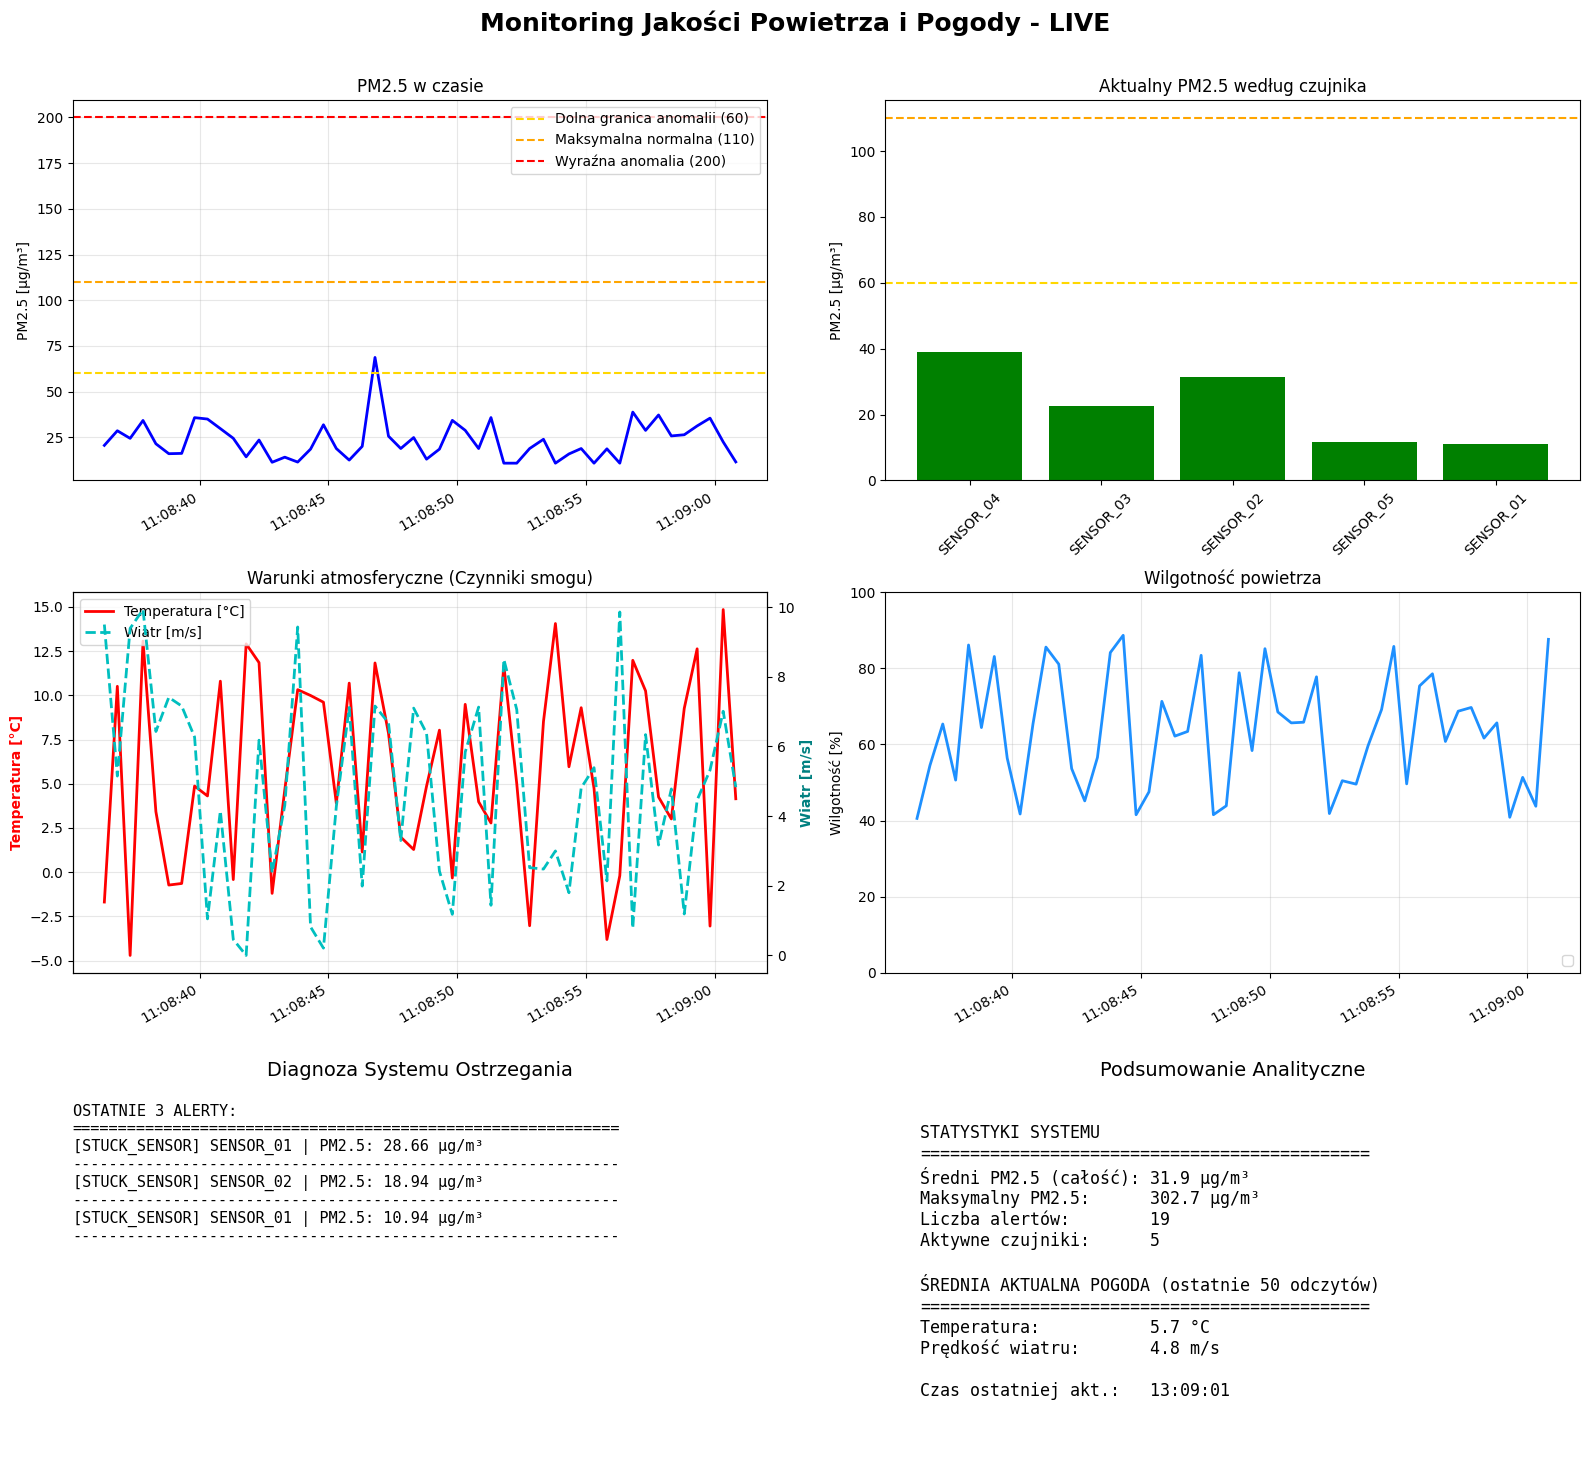

In [ ]:
####

## Tworzy rozbudowany dashboard z 6 panelami:
##
## Panel 1 (lewy górny): PM2.5 w czasie
##   - Wykres liniowy z ostatnich 50 odczytów (readings_short)
##   - Linie pomocnicze dla orientacji (wizualne, NIE definiują alertów):
##       * 60 µg/m³: dolna granica potencjalnych anomalii
##       * 110 µg/m³: maksymalna normalna wartość (wg generatora)
##       * 200 µg/m³: wyraźna anomalia
##
## Panel 2 (prawy górny): Aktualne wartości czujników
##   - Wykres słupkowy dla każdego czujnika
##   - Kolorowanie wizualne (NIE definiuje alertów):
##       * Zielony: < 60 µg/m³ (typowe normalne)
##       * Żółty/pomarańczowy: 60-110 µg/m³ (górna granica normy)
##       * Czerwony: > 110 µg/m³ (prawdopodobna anomalia)
##
## Panel 3 (lewy środkowy): Temperatura i Wiatr
##   - Wykres liniowy z podwójną osią Y (twinx)
##   - Pokazuje korelację temperatury i siły wiatru w czasie
##
## Panel 4 (prawy środkowy):
##   - Wilgotność powietrza
##
## Panel 5 (lewy dolny): Diagnoza Systemu Ostrzegania (Alerty)
##   - Wyświetla 3 ostatnie alerty z Kafki
##   - Prezentuje objaśnienia modelu ML
##
## Panel 6 (prawy dolny): Podsumowanie Analityczne
##   - Statystyki ogólne: średni i maksymalny PM2.5, liczba alertów
##   - Średnia pogoda dla ostatnich 50 odczytów oraz aktualny czas

####

from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime, timedelta
import time
import textwrap

while True:
    clear_output(wait=True)

    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    fig.suptitle('Monitoring Jakości Powietrza i Pogody - LIVE', fontsize=18, fontweight='bold', y=0.98)
    
    # ===== 1. PM2.5 w czasie (Lewy Górny) =====
    if readings_short:
        times = [r['timestamp'] for r in readings_short]
        pm25_vals = [r.get('pm25', 0) for r in readings_short]
        axes[0,0].plot(times, pm25_vals, 'b-', linewidth=2)
        # Linie wizualne
        axes[0,0].axhline(y=60, color='gold', linestyle='--', linewidth=1.5, label='Dolna granica anomalii (60)')
        axes[0,0].axhline(y=110, color='orange', linestyle='--', linewidth=1.5, label='Maksymalna normalna (110)')
        axes[0,0].axhline(y=200, color='red', linestyle='--', linewidth=1.5, label='Wyraźna anomalia (200)')
        axes[0,0].set_ylabel('PM2.5 [µg/m³]')
        axes[0,0].set_title('PM2.5 w czasie')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=30, ha='right')
    
    # ===== 2. Aktualne wartości czujników (Prawy Górny) =====
    if sensor_data:
        sensors = list(sensor_data.keys())
        values = list(sensor_data.values())
        # Kolorowanie
        colors = ['red' if v > 110 else 'orange' if v > 60 else 'green' for v in values]
        axes[0,1].bar(sensors, values, color=colors)
        axes[0,1].axhline(y=60, color='gold', linestyle='--', linewidth=1.5)
        axes[0,1].axhline(y=110, color='orange', linestyle='--', linewidth=1.5)
        axes[0,1].set_ylabel('PM2.5 [µg/m³]')
        axes[0,1].set_title('Aktualny PM2.5 według czujnika')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # ===== 3. Temperatura i Wiatr (Lewy Środkowy) =====
    if readings_short:
        times = [r['timestamp'] for r in readings_short]
        temp_vals = [r.get('temperature', 0) for r in readings_short]
        wind_vals = [r.get('wind_speed', 0) for r in readings_short]
        
        ax_temp = axes[1,0]
        ax_wind = ax_temp.twinx()
        
        ax_temp.plot(times, temp_vals, 'r-', linewidth=2, label='Temperatura [°C]')
        ax_wind.plot(times, wind_vals, 'c--', linewidth=2, label='Wiatr [m/s]')
        
        ax_temp.set_ylabel('Temperatura [°C]', color='red', fontweight='bold')
        ax_wind.set_ylabel('Wiatr [m/s]', color='teal', fontweight='bold')
        ax_temp.set_title('Warunki atmosferyczne (Czynniki smogu)')
        
        # Wspólna legenda dla obu osi
        lines_1, labels_1 = ax_temp.get_legend_handles_labels()
        lines_2, labels_2 = ax_wind.get_legend_handles_labels()
        ax_temp.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
        
        ax_temp.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        plt.setp(ax_temp.xaxis.get_majorticklabels(), rotation=30, ha='right')
        ax_temp.grid(True, alpha=0.3)

    # ===== 4. Wilgotność (Prawy Środkowy) =====
    if readings_short:
        times = [r['timestamp'] for r in readings_short]
        hum_vals = [r.get('humidity', 0) for r in readings_short]
        
        axes[1,1].plot(times, hum_vals, 'dodgerblue', linewidth=2)
        axes[1,1].set_ylim(0, 100)
        axes[1,1].set_ylabel('Wilgotność [%]')
        axes[1,1].set_title('Wilgotność powietrza')
        axes[1,1].legend(loc='lower right')
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # ===== 5. Alerty i Diagnoza ML (Lewy Dolny) =====
    axes[2,0].axis('off')
    if alerts:
        alert_text = "OSTATNIE 3 ALERTY:\n" + "=" * 60 + "\n"
        for a in list(alerts)[-3:]:
            alert_type = a.get('alert_type', 'UNKNOWN')
            sensor_id = a.get('sensor_id', '?')
            pm25 = a.get('pm25', '?')
            
            alert_text += f"[{alert_type}] {sensor_id} | PM2.5: {pm25} µg/m³\n"
            
            if alert_type == 'LOCAL_EXPLOSION':
                temp = a.get('temperature', 'N/A')
                wind = a.get('wind_speed', 'N/A')
                hum = a.get('humidity', 'N/A')
                reason = a.get('alert_reason', 'Analiza modelu ML')

                wrapped_reason = textwrap.fill(reason, width=50, subsequent_indent="      ")
                
                alert_text += f"   ├─ Pogoda: {temp}°C | Wiatr: {wind}m/s | Wilg: {hum}%\n"
                alert_text += f"   └─ Powód: {wrapped_reason}\n"
                
            alert_text += "-" * 60 + "\n"
            
        axes[2,0].text(0.0, 0.95, alert_text, fontsize=11, verticalalignment='top', family='monospace')
    else:
        axes[2,0].text(0.5, 0.5, "BRAK ALERTÓW", fontsize=16, ha='center', color='green', weight='bold')
    axes[2,0].set_title('Diagnoza Systemu Ostrzegania', fontsize=14)
    
    # ===== 6. Statystyki (Prawy Dolny) =====
    axes[2,1].axis('off')
    if readings:
        pm25_vals = [r.get('pm25', 0) for r in readings]
        temp_vals = [r.get('temperature', 0) for r in readings_short]
        wind_vals = [r.get('wind_speed', 0) for r in readings_short]
        
        stats = f"""
STATYSTYKI SYSTEMU
{'=' * 45}
Średni PM2.5 (całość): {np.mean(pm25_vals):.1f} µg/m³
Maksymalny PM2.5:      {max(pm25_vals):.1f} µg/m³
Liczba alertów:        {len(alerts)}
Aktywne czujniki:      {len(sensor_data)}

ŚREDNIA AKTUALNA POGODA (ostatnie 50 odczytów)
{'=' * 45}
Temperatura:           {np.mean(temp_vals):.1f} °C
Prędkość wiatru:       {np.mean(wind_vals):.1f} m/s

Czas ostatniej akt.:   {(datetime.now() + timedelta(hours=2)).strftime('%H:%M:%S')}
        """
        axes[2,1].text(0.05, 0.95, stats, fontsize=12, verticalalignment='top', family='monospace')
    axes[2,1].set_title('Podsumowanie Analityczne', fontsize=14)
    
    # Poprawia marginesy, żeby napisy nie nachodziły na siebie
    plt.tight_layout()
    # Mała korekta układu ze względu na główny tytuł (suptitle)
    fig.subplots_adjust(top=0.92) 
    
    plt.show()
    
    time.sleep(0.5)